In [1]:
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/")

import matplotlib.pyplot as plt
import numpy as np
import pickle
from tqdm import tqdm
import pandas as pd
import json
from pathlib import Path

import numpy as np
import seaborn as sns
import os

In [2]:
from analysis.utils import load_sweep_metadata, load_data
from analysis.utils_decoding import evaluate_lags_leave_k_out

In [3]:
def compute_success(df_data,
                    threshold_angle=0.1,
                    consecutive_steps=100,
                    starting_step=0,
                    column_name=None):
    """
    Compute whether the pole is upright (straight) for consecutive_steps time points.
    
    Args:
        df_data: DataFrame with 'observations' column containing state arrays
        threshold_angle: Maximum angle deviation from vertical (in radians) to consider "straight"
        consecutive_steps: Number of consecutive steps required for success
    
    Returns:
        df_data: DataFrame with added 'success' column
    """
    success = []

    for idx in range(len(df_data)):
        observations = np.array(df_data['observations'].iloc[idx])
        observations = observations[starting_step:]

        # Extract cos and sin of pole angle (dimensions 1 and 2)
        cos_angle = observations[:, 1]
        sin_angle = observations[:, 2]

        # Compute actual angle from cos and sin
        angles = np.arctan2(sin_angle, cos_angle)

        # Check if angle is within threshold (close to 0, which is upright)
        is_straight = np.abs(angles) < threshold_angle

        # Check for consecutive_steps consecutive True values
        episode_success = False
        count = 0
        for straight in is_straight:
            if straight:
                count += 1
                if count >= consecutive_steps:
                    episode_success = True
                    break
            else:
                count = 0

        success.append(episode_success)
    column_name = column_name if column_name is not None else 'success'
    df_data[column_name] = np.array(success)
    return df_data


def chunk_data(data, chunk_size=500):
    return [data[i:i + chunk_size] for i in range(0, len(data), chunk_size)]


In [4]:
df_metadata = load_sweep_metadata(
    ["logs/25-12-09-cartpole_initial_conditions_seeds_models"],
    json_file_name='episode_metadata.json')


Dirs in logs/25-12-09-cartpole_initial_conditions_seeds_models: 100%|██████████| 825/825 [00:00<00:00, 862.94it/s] 

Found 825 configurations


In [5]:
df_metadata = df_metadata[
    (df_metadata['checkpoint'] == 'ckpts/cartpole-swingup-3.pt') &
    (df_metadata['seed'] == 1)]

In [6]:
df = load_data(
    df_metadata,
    episode_file_name='episode_data.pkl',
    cart_position=0.,
)
df = compute_success(df, starting_step=300, consecutive_steps=200)

Found 11 configurations


100%|██████████| 11/11 [00:00<00:00, 190.56it/s]


In [7]:
dim_names = {
    0: 'Cart Position',
    1: 'cos(Pole Angle)',
    2: 'sin(Pole Angle)',
    3: 'Cart Velocity',
    4: 'Pole Angular Velocity',
}

In [8]:
df['init_cart_position'] = df['initial_state'].apply(lambda x: x[0])
df['init_pole_angle'] = df['initial_state'].apply(lambda x: x[1])
df['init_pole_angle_degrees'] = np.degrees(df['init_pole_angle'])
df['init_pole_angle_str'] = df['init_pole_angle_degrees'].round(0).astype(str)

for dim in range(5):
    df[f'average_dim_{dim}'] = df['observations'].apply(
        lambda x: np.mean(np.array(x)[:, dim]))

df['total_position_change'] = df['observations'].apply(
    lambda x: np.array(x)[-1, 0] - np.array(x)[0, 0])

df['cumulative_abs_position_change'] = df['observations'].apply(
    lambda x: np.sum(np.abs(np.diff(np.array(x)[:, 0]))))

df['cumulative_position_change'] = df['observations'].apply(
    lambda x: np.sum(np.diff(np.array(x)[:, 0])))

In [46]:
df = df[~df['init_pole_angle_degrees'].isin([0, 360])]

In [47]:
df.shape

(9, 30)

In [48]:
def process_data(df_model, threshold=0.99):
    obs = np.concatenate(df_model['observations'].tolist())
    z = np.concatenate(df_model['latent_states'].tolist())
    rewards = np.concatenate(df_model['rewards'].tolist())
    actions = np.concatenate(df_model['actions'].tolist())

    cos_pole_angle = obs[:, 1]
    stabilization_mask = (cos_pole_angle >= threshold)
    swingup_mask = ~stabilization_mask

    obs_stabilization = obs[stabilization_mask]
    obs_swingup = obs[swingup_mask]
    z_stabilization = z[stabilization_mask]
    z_swingup = z[swingup_mask]
    rewards_stabilization = rewards[stabilization_mask]
    rewards_swingup = rewards[swingup_mask]
    actions_stabilization = actions[stabilization_mask]
    actions_swingup = actions[swingup_mask]
    return {
        'obs': obs,
        'obs_stabilization': obs_stabilization,
        'obs_swingup': obs_swingup,
        'z': z,
        'z_stabilization': z_stabilization,
        'z_swingup': z_swingup,
        'rewards': rewards.reshape(-1, 1),
        'rewards_stabilization': rewards_stabilization.reshape(-1, 1),
        'rewards_swingup': rewards_swingup.reshape(-1, 1),
        'actions': actions,
        'actions_stabilization': actions_stabilization,
        'actions_swingup': actions_swingup,
        'stabilization_mask': stabilization_mask,
        'swingup_mask': swingup_mask
    }


In [49]:
# Process data for each model
results = process_data(df)

In [50]:
all_combs = [
    ('z', 'obs'),
    ('z', 'rewards'),
    ('z', 'actions'),
    ('obs', 'obs'),
    ('rewards', 'rewards'),
    ('actions', 'actions'),
]

stabilization_combs = [
    ('z_stabilization', 'obs_stabilization'),
    ('z_stabilization', 'rewards_stabilization'),
    ('z_stabilization', 'actions_stabilization'),
    ('obs_stabilization', 'obs_stabilization'),
    ('rewards_stabilization', 'rewards_stabilization'),
    ('actions_stabilization', 'actions_stabilization'),
]

swingup_combs = [
    ('z_swingup', 'obs_swingup'),
    ('z_swingup', 'rewards_swingup'),
    ('z_swingup', 'actions_swingup'),
    ('obs_swingup', 'obs_swingup'),
    ('rewards_swingup', 'rewards_swingup'),
    ('actions_swingup', 'actions_swingup'),
]

In [57]:
path_to_save = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/outputs_workshop_121225'
for k, v in {
        'all': all_combs,
        # 'stabilization': stabilization_combs,
        # 'swingup': swingup_combs
}.items():
    results_decoding = {}
    for x_var, y_var in v:
        print(f"Decoding {x_var} -> {y_var}")
        results_decoding[f'{x_var}-{y_var}'] = evaluate_lags_leave_k_out(
            chunk_data(results[x_var]),
            chunk_data(results[y_var]),
            model='lasso',
            lags=np.arange(-80, 81, 5),
            k_holdout=1,
            add_bootstrap_ci=True,
            shuffle_X=False,
            shuffle_y=False)

    #Save results_decoding to pickle file
    with open(
            os.path.join(path_to_save,
                         f'results_decoding_lasso_{k}_no0-360egrees.pkl'),
            'wb') as f:
        pickle.dump(results_decoding, f)

Decoding z -> obs


  0%|          | 0/9 [00:00<?, ?it/s]/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.431e+03, tolerance: 2.281e+00
  model = cd_fast.enet_coordinate_descent(
/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.491e-01, tolerance: 1.876e-01
  model = cd_fast.enet_coordinate_descent(
/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want

Decoding z -> rewards


 67%|██████▋   | 6/9 [00:30<00:14,  5.00s/it]/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.474e-01, tolerance: 1.222e-01
  model = cd_fast.enet_coordinate_descent(
100%|██████████| 9/9 [00:46<00:00,  5.12s/it]


Decoding z -> actions


...

100%|██████████| 9/9 [00:00<00:00, 14.07it/s]


Decoding rewards -> rewards


100%|██████████| 9/9 [00:00<00:00, 25.44it/s]


Decoding actions -> actions


100%|██████████| 9/9 [00:00<00:00, 24.94it/s]


In [58]:
path_to_save = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/outputs_workshop_121225'
with open(
        os.path.join(path_to_save,
                     'results_decoding_lasso_all_no0-360egrees.pkl'),
        'rb') as f:
    results_decoding_all = pickle.load(f)


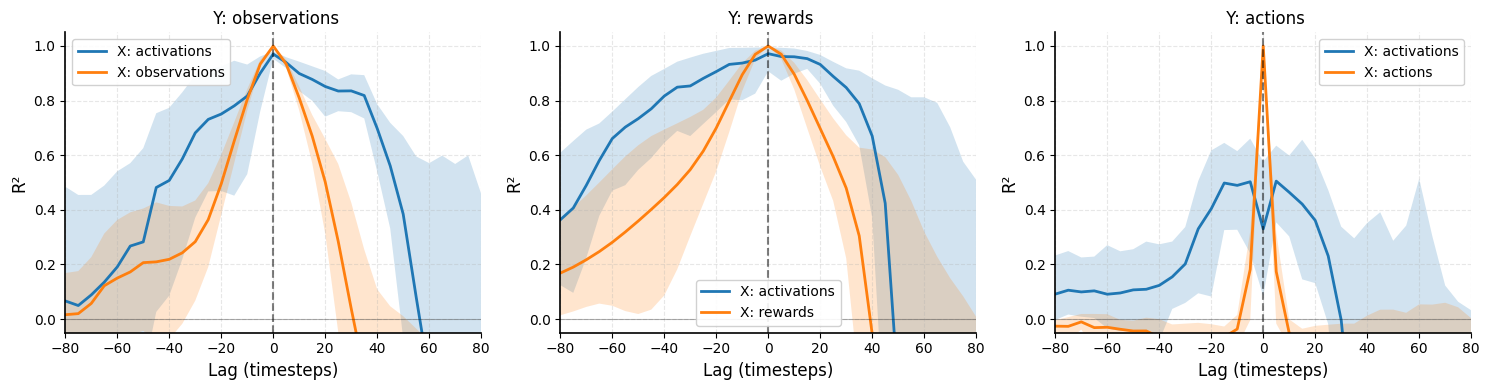

In [71]:
plot_dict = {
    0: ['z-obs', 'obs-obs'],
    1: ['z-rewards', 'rewards-rewards'],
    2: ['z-actions', 'actions-actions']
}

map_dict = {
    'z': 'activations',
    'obs': 'observations',
    'rewards': 'rewards',
    'actions': 'actions'
}

# Create a figure with as many subplots as keys in plot_dict
num_plots = len(plot_dict)
fig, axes = plt.subplots(1, num_plots, figsize=(15, 4))

# Handle case where there's only one subplot
if num_plots == 1:
    axes = [axes]

# Iterate through plot_dict
for plot_idx, key_list in plot_dict.items():
    ax = axes[plot_idx]

    # Plot each key in the list for this subplot
    for key in key_list:
        if key in results_decoding_all:
            results = results_decoding_all[key]

            r2_mean = results['r2_mean']
            r2_ci = results['r2_ci']

            # Extract lags and R² values from the dictionary
            lags = list(r2_mean.keys())
            means = list(r2_mean.values())

            # r2_ci is a tuple of (lower_dict, upper_dict)
            ci_lower = [r2_ci[lag][0] for lag in lags]
            ci_upper = [r2_ci[lag][1] for lag in lags]

            # Plot with label based on the key
            title = key.split('-')
            label = f'X: {map_dict[title[0]]}'
            ax.plot(lags, means, label=label, linewidth=2)
            ax.fill_between(lags, ci_lower, ci_upper, alpha=0.2)

    ax.set_xlabel('Lag (timesteps)', fontsize=12)
    ax.set_ylabel('R²', fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.5, linewidth=1.5)
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
    ax.legend(fontsize=10, framealpha=0.9)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(-80, 80)
    ax.tick_params(labelsize=10)
    ax.set_title(f' Y: {map_dict[title[1]]}')
    # Add spines styling
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

#plt.suptitle('Decoding Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
sns.despine()
plt.show()

In [56]:
z_all.shape

(4500, 512)

In [53]:
mask_stabilization = obs_all[:, 1] >= 0.99
mask_swingup = ~mask_stabilization

z_stabilization = z_all[mask_stabilization]
z_swingup = z_all[mask_swingup]
rewards_stabilization = rewards_all[mask_stabilization]
rewards_swingup = rewards_all[mask_swingup]
obs_stabilization = obs_all[mask_stabilization]
obs_swingup = obs_all[mask_swingup]

In [55]:
from sklearn.model_selection import train_test_split

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(z_swingup,
                                                    obs_swingup,
                                                    test_size=0.2,
                                                    random_state=42)

# Fit linear regression model
model_stabilization = LinearRegression()
model_stabilization.fit(X_train, y_train)

# Predict and calculate R²
y_pred_train = model_stabilization.predict(X_train)
y_pred_test = model_stabilization.predict(X_test)

r2_train = r2_score(y_train, y_pred_train, multioutput='variance_weighted')
r2_test = r2_score(y_test, y_pred_test, multioutput='variance_weighted')

print(f"Train R² score: {r2_train:.4f}")
print(f"Test R² score: {r2_test:.4f}")


Train R² score: 1.0000
Test R² score: 1.0000
